<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/ML/Home_Komment_LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


Коментар 1
   - завантажуємо потрібні бібліртеки для роботи з файлами та нашим гарфіком
   - завантажуємо інструманти для створення та оцінки лінійної регресії.
   - створюємо модель (model = LinearRegression())
   - створюємо рандом замість завантаження реальний даних. Фіксуємо рандом в одному стані.
   - налаштовуємо вигляд таблиці(колонок)

У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [3]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()


,area,rooms,floor,dist_km,age_years,price
0,69.9,4,6,2.6,14,172.1
1,57.2,3,11,6.4,30,122.8
2,73.0,3,3,2.4,54,146.3
3,90.5,3,8,3.4,13,217.6
4,55.3,3,3,2.8,10,165.2


**Коментар 2**
- гереруємо значення для рандому для 1000 квартир. за площеєю Середнє 60кв.м та стандартне відхилення від нього 20кв.м.
- генеруємо  значення для кімнат де обмежуємо модель до 5 кімнат, визначаємо що кожні 25 кв.м це 1 кімната та задаємо відхилення 0,6(кімнати) для реалістичності, округлюємо значення
- генеруємо кількість поверхів
- генеруємо відстань від центру де середнє значення 5км., а максимальне 25. тобто скупчення значень ближче до центру за допомогою random.exponential(5, n) та обрізаємо рандомну вибірку з 0,3 до 25 км.
- генеруємо вибірку для року забудови, рівномірно від 1 до 60 років.
+ додаємо загальний шум з розкидом(std) по ціні в районі 12 тис дол та обрізаємо мінімальну ціну на значенні 20тис.дол для реалістичнішого розподілу

Створюємо ДатаФрейм з нашим набором данних, де значення наші рандомні задані значення.
Виводимо його для наглядності

In [4]:
len(df)
print(df.shape[0], df.shape[1])

1000 6


In [5]:
print("Пропуски - ", df.isna().sum().sum())
#

Пропуски -  0


In [6]:
df.describe()

,area,rooms,floor,dist_km,age_years,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,60.492200,2.479000,12.686000,4.958100,30.391000,136.250900
std,19.328422,0.951033,7.004889,4.708852,17.232326,44.993968
min,20.000000,1.000000,1.000000,0.300000,0.000000,20.000000
25%,47.075000,2.000000,6.000000,1.500000,16.000000,104.150000
50%,60.500000,2.000000,13.000000,3.600000,30.000000,136.750000
75%,73.000000,3.000000,19.000000,7.000000,45.250000,165.450000
max,137.100000,5.000000,24.000000,25.000000,59.000000,282.400000


Коментар 3
- робимо перевірку на пропуски
- виводимо статистику

Text(0.5, 1.0, 'Залежність ціни від площі')

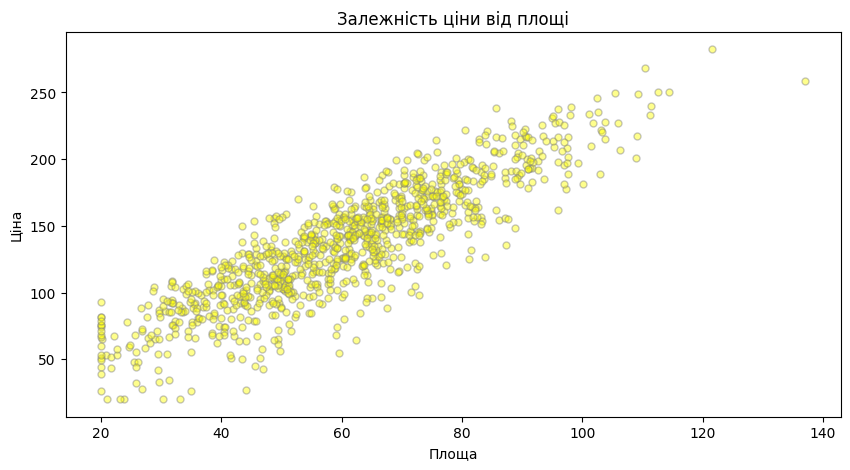

In [15]:

fig = plt.figure(figsize=(10, 5))
plt.scatter(df["area"], df["price"], edgecolors="grey", color="yellow", alpha=0.45, s=25)
plt.xlabel("Площа")
plt.ylabel("Ціна")
plt.title("Залежність ціни від площі")





Коментар 4
- Створюємо діаграму росзіювання для наглядності, де видно чітку залежність між ціною та площею, а також значення інших факторів. це показує ширина розподілу наших бульбашок(шампанського) відносно основного тренду. Також видно що дані містять викиди за ціною в пределах  реальності.

In [16]:
df.columns

Index(['area', 'rooms', 'floor', 'dist_km', 'age_years', 'price'], dtype='object')

In [17]:
X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']] # features
y = df["price"] # target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
print("Навчальна вибірка", X_train.shape, "\n", "Тестова вибірка", X_test.shape)

Навчальна вибірка (800, 5) 
 Тестова вибірка (200, 5)


Коментар 5
  - Задаємо моделі параметри для вивчення взаємозвязку між данними параметрами та ціною .
  - Х - це ДатаФрейм з нашими рандомно згенерованими параметрами, заданими спеціальним чином.
  - y - маленька , це наша ціна, яку ми даємо моделі для знаходження взаємозвязків.
  - Далі розділяємо нашу таблицю даних на навчальну та тестову вибірку у відностності 20%-для тестових даних, 80% для навчаних, щоб модель мала змогу знайти закономірності нежалежно від тренувальних даниих. Дані розподіляються рандомно та фіксуються (Random_STATE)
  - Виводимо кількість значень в обох вибірках, видно правилний розподіл

| X | y | **X_train** | X_test | **y_train** | y_test | y_pred |
| - | - | ------- | ------ | ------- | ------ | -- |
| 1 | 1 | 1 |  | 1 |  |  |
| 2 | 4 | 2 |  | 4 |  |  |
| 3 | 9 |  | 3 |  | 9 | 90 |
| 4 | 16 | 4 |  | 16 |  |  |
| 5 | 25 |  | 5 |  | 25 | 250 |
| 6 | 36 | 6 |  | 36 |  |  |
| 7 | 49 | 7 |  | 49 |  |  |
| 8 | 64 | 8 |  | 64 |  |  |
| 9 | 81 | 9 |  | 81 |  |  |
| 10 | 100 | 10 |  | 100 |  |  |
| 11 |  |  |  |  |  | 1210 |

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    "Actual": y_test[:].round(),
    "Predicted": y_pred[:].round()

})
#compare["error"] = compare["Actual"] - compare["Predicted"]
#compare["error_abs"] = compare["error"].abs()
compare["error_pct_abs"] = ((compare["Predicted"] - compare["Actual"]) / compare["Actual"] * 100).round(1).abs()
compare.head(10)


,Actual,Predicted,error_pct_abs
521,119.0,130.0,9.2
737,173.0,178.0,2.9
740,20.0,26.0,30.0
660,94.0,111.0,18.1
411,101.0,97.0,4.0
678,186.0,189.0,1.6
626,98.0,87.0,11.2
513,112.0,106.0,5.4
859,171.0,189.0,10.5
136,90.0,92.0,2.2


In [33]:
compare["error_pct_abs"].mean().round(2)

np.float64(9.51)

In [37]:
print(f"Середня абсолютна похибка: {compare['error_pct_abs'].mean():.1f}%")
print(f"Максимальна похибка: {compare['error_pct_abs'].max():.1f}%")
print(f"Мінімальна похибка: {compare['error_pct_abs'].min():.1f}%")

Середня абсолютна похибка: 8.0%
Максимальна похибка: 73.1%
Мінімальна похибка: 0.0%


Коментарій 6
 - Передаємо значення для навчання в нашу модель для X та y (model.fit(X_train, y_train))
 - Передаємо значення з тестової вибірки(20% від інших данних) для  прогнозу (model.predict(X_test))
 - робимо таблицю - порівняння розрахунку ціни в результаті навчання та в результаті створення ціни на тестових данних.
 - Виводимо дані в фактичних значеннях та у відсотках для наглядності.
 - ІЗ даних видно що модель справляється по різному з похибкою від 0 до 73 відсотків, але в середньому вона складає 9.51%
 Щоб робити остаточні висновки, необхідно подивитися на інші показники оцінки моделі (MAe, MSE, RMSE,R²)

In [ ]:
#MAE # mean absolut error на скільки наша модель помилилися в середньому


In [ ]:
#MSE # mean scquare error

In [ ]:
#RMSE # показує *(корінь квадратний з MSE) - чим меньше значення тим краще

In [ ]:
#R² - яку частину розкиду модель може оцінити [0:1.0] 1ideal, - 0 вгадує середній показник

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.1f}K $ in mean error")
print(f"MSE: {mse:.1f}K $")
print(f"RMSE: {rmse:.2f}K $")
print(f"R²: {r2*100:.3f} model describe % from real price")

MAE: 8.7K $ in mean error
MSE: 117.3K $
RMSE: 10.83K $
R²: 94.699 model describe % from real price


Коментарій 7
 - Розраховуємо значення MAe, MSE, RMSE,R² та виводим їх
 - -  MAE показує похибку в грошовий одиницях, на скільки модель помиляється в нашому випадку на 8,7 тис.дол, що є не великим показником, вкаховуючи середню ціну
 - - MSE - це та сама похибка, але зведена в квадрат
 -- RMSE - це корінь від MSE, але враховуючи великі викиди
 - - R² - показує наскільки наша модель навчана, скількі відсотків даннних вона вірно повертає. 94,7% - це дуже добрий показник, такій моделі можна довіряти

In [38]:
coef = pd.DataFrame({
    "features" : X.columns,
    "coef" : model.coef_.round(2)
    }).sort_values(by="coef", ascending=False)
print("Basic Prica", model.intercept_.round(2), "K $")
print("Depends of price")

coef


Basic Prica 40.83 K $
Depends of price


,features,coef
1,rooms,5.22
0,area,1.78
2,floor,0.39
4,age_years,-0.49
3,dist_km,-3.07


In [ ]:
price2 = (
    40.83
    + area *	1.78
    + rooms * 5.22
    + dist_km	* (-3.07)
    + age_years	* (-0.49)
    + floor * (0.39)
)


# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

оментарій 7

 - Розраховуємо значення MAe, MSE, RMSE,R² та виводим їх
 - MAE показує похибку в грошовий одиницях, на скільки модель помиляється в нашому випадку на 8,7 тис.дол, що є не великим показником, вкаховуючи середню ціну
 - MSE - це та сама похибка, але зведена в квадрат -- RMSE - це корінь від MSE, але враховуючи великі викиди
 - R² - показує наскільки наша модель навчана, скількі відсотків даннних вона вірно повертає. 94,7% - це дуже добрий показник, такій моделі можна довіряти
Далі ми порідняли задані наші коефіцієнти для навчання та ті які реально вийшли на тестових данних. Рзниця вийшла мінімальна, шо підтверджує показник R²

In [ ]:
new_flat = pd.DataFrame([{
    'area':68, 'rooms':2, 'floor':2, 'dist_km':15, 'age_years':10
}])
new_flat
print(f"+/-: {mae:.1f} тис дол.")
print("Ймовірна ціна:", f"{model.predict(new_flat)[0]:.2f}")
#print(f"Яке рішення прийме: {"Піде" if model.predict(new_client)[0] else "Залишиться"}" )
#

+/-: 8.7 тис дол.
Ймовірна ціна: 122.36
